# Modelado segmentado de consumo — predicción a 3 y 6 meses

## Objetivo

Esta versión reemplaza el enfoque de un único modelo global por una arquitectura de **modelos especializados según el comportamiento histórico de cada consumidor**.

Todo el cálculo de perfiles, incluyendo la identificación y auditoría de **grandes consumidores**, se realiza dentro de este mismo notebook. No requiere un archivo de clasificación externo.

El notebook parte únicamente de:

`serie_mensual_modelado_preprocesada.parquet`

## Perfiles de consumo

La clasificación se calcula **en cada fecha de corte**, usando exclusivamente los últimos 12 meses conocidos hasta esa fecha:

- `P0_INTERMITENTE`: consumo muy bajo o alta frecuencia de ceros.
- `P1_REGULAR`: consumidor regular de escala baja/media.
- `P2_ALTO`: consumidor de escala alta.
- `P3_GRANDE`: gran consumidor persistente.
- `P4_INSUFICIENTE`: cliente con poca historia; utiliza fallback estacional.

Los perfiles se definen a partir de la **mediana histórica de 12 meses**, no del consumo futuro que queremos predecir. Esto evita fuga de información.

## Tratamiento distinto por perfil

### P0 — Intermitente
Modelo hurdle de dos etapas:
1. LightGBM Classifier estima la probabilidad de que el consumo sea mayor que cero.
2. LightGBM Regressor estima el consumo positivo.
3. Pronóstico esperado = probabilidad × consumo positivo.

### P1 — Regular
LightGBM independiente por horizonte con `log1p(consumo)`.

### P2 — Alto
LightGBM **Tweedie** independiente por horizonte y usando todos los clientes disponibles del segmento.

### P3 — Grande
LightGBM **Tweedie** especializado, entrenado con **todos** los grandes consumidores disponibles. Después se combina con un baseline estacional mediante un peso `alpha` optimizado en validación.

### P4 — Historia insuficiente
No se fuerza un modelo ML con poca evidencia. Se utiliza el baseline estacional / último valor conocido.

## Horizontes

Se entrenan modelos independientes para:

`t+1, t+2, t+3, t+4, t+5, t+6`

## Evaluación

Se calcula:

- MAE
- RMSE
- WAPE
- sMAPE
- R²
- sesgo total
- métricas por perfil
- métricas por horizonte
- métricas por régimen observado/reconstruido
- real vs. pronosticado cliente por cliente

El sistema segmentado se compara siempre contra un baseline estacional.

## Dependencias

Si LightGBM no está instalado:

```python
%pip install -U lightgbm scikit-learn pyarrow joblib
```

Después reinicia el kernel y ejecuta nuevamente desde el inicio.

In [1]:
# ============================================================
# 1. LIBRERÍAS Y RUTAS
# ============================================================

from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import joblib

try:
    from lightgbm import (
        LGBMRegressor,
        LGBMClassifier,
    )
except ImportError as e:
    raise ImportError(
        "Falta LightGBM. Ejecuta: %pip install -U lightgbm"
    ) from e

warnings.filterwarnings("ignore")

BASE_DIR = Path(
    r"C:\Users\Home\Documents\Datos Ebsa"
)

PREPROC_DIR = (
    BASE_DIR
    / "Serie_tiempo_consumo"
    / "preprocesamiento_modelo"
)

RUTA_ENTRADA = (
    PREPROC_DIR
    / "serie_mensual_modelado_preprocesada.parquet"
)

SALIDA_DIR = (
    BASE_DIR
    / "Serie_tiempo_consumo"
    / "modelacion_consumo_segmentada"
)

SALIDA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RUTA_PERFILES_FINAL = (
    SALIDA_DIR
    / "perfiles_consumidores_corte_final.parquet"
)

RUTA_GRANDES_FINAL = (
    SALIDA_DIR
    / "grandes_consumidores_corte_final.parquet"
)

RUTA_AUDITORIA_UMBRALES = (
    SALIDA_DIR
    / "auditoria_umbrales_grandes_consumidores.csv"
)

RUTA_ALPHA = (
    SALIDA_DIR
    / "alpha_blend_por_perfil_horizonte.csv"
)

RUTA_METRICAS_VALIDACION = (
    SALIDA_DIR
    / "metricas_segmentadas_validacion.csv"
)

RUTA_METRICAS_BACKTEST = (
    SALIDA_DIR
    / "metricas_segmentadas_backtest.csv"
)

RUTA_METRICAS_PERFIL = (
    SALIDA_DIR
    / "metricas_por_perfil_horizonte.csv"
)

RUTA_METRICAS_REGIMEN = (
    SALIDA_DIR
    / "metricas_por_regimen_horizonte.csv"
)

RUTA_REAL_VS_PRED = (
    SALIDA_DIR
    / "real_vs_pronosticado_segmentado_backtest.parquet"
)

RUTA_MODELOS = (
    SALIDA_DIR
    / "modelos_segmentados_consumo.joblib"
)

RUTA_PRED_3M = (
    SALIDA_DIR
    / "predicciones_segmentadas_consumo_3_meses.parquet"
)

RUTA_PRED_6M = (
    SALIDA_DIR
    / "predicciones_segmentadas_consumo_6_meses.parquet"
)

print("Entrada :", RUTA_ENTRADA)
print("Salidas :", SALIDA_DIR)

Entrada : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\preprocesamiento_modelo\serie_mensual_modelado_preprocesada.parquet
Salidas : C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada


In [2]:
# ============================================================
# 2. CONFIGURACIÓN DE PERFILES Y BACKTEST
# ============================================================

SEED = 42

HORIZONTES = [
    1, 2, 3, 4, 5, 6
]

# ------------------------------------------------------------
# Reglas de segmentación
# ------------------------------------------------------------

MIN_MESES_VALIDOS_12 = 6

UMBRAL_MUY_BAJO_KWH = 10.0
UMBRAL_ALTO_KWH = 500.0
UMBRAL_GRANDE_KWH = 5_000.0

PCT_CEROS_INTERMITENTE = 0.50

PERFILES = [
    "P0_INTERMITENTE",
    "P1_REGULAR",
    "P2_ALTO",
    "P3_GRANDE",
    "P4_INSUFICIENTE",
]

# ------------------------------------------------------------
# Muestreo por perfil
#
# P2 y P3 se entrenan con TODOS los registros disponibles.
# ------------------------------------------------------------

MAX_MUESTRA_POR_ORIGEN = {
    "P0_INTERMITENTE": 40_000,
    "P1_REGULAR": 60_000,
    "P2_ALTO": None,
    "P3_GRANDE": None,
}

# ------------------------------------------------------------
# Esquema temporal
# ------------------------------------------------------------

PRIMER_ORIGEN_TRAIN = pd.Timestamp(
    "2023-01-01"
)

MAX_TARGET_TRAIN_COMPARACION = pd.Timestamp(
    "2024-07-01"
)

CORTES_VALIDACION = [
    pd.Timestamp("2024-07-01"),
    pd.Timestamp("2025-01-01"),
]

CORTE_BACKTEST_FINAL = pd.Timestamp(
    "2025-07-01"
)

# Pesos candidatos para combinar ML y baseline.
GRID_ALPHA = np.round(
    np.linspace(
        0.0,
        1.0,
        21,
    ),
    2,
)

print("PERFILES")
print("-" * 60)
print(
    f"P0: mediana <= {UMBRAL_MUY_BAJO_KWH:,.0f} kWh "
    f"o ceros >= {PCT_CEROS_INTERMITENTE:.0%}"
)
print(
    f"P1: > {UMBRAL_MUY_BAJO_KWH:,.0f} "
    f"y < {UMBRAL_ALTO_KWH:,.0f} kWh"
)
print(
    f"P2: {UMBRAL_ALTO_KWH:,.0f} "
    f"a < {UMBRAL_GRANDE_KWH:,.0f} kWh"
)
print(
    f"P3: >= {UMBRAL_GRANDE_KWH:,.0f} kWh "
    "de mediana histórica 12m"
)
print(
    f"P4: < {MIN_MESES_VALIDOS_12} meses válidos"
)

PERFILES
------------------------------------------------------------
P0: mediana <= 10 kWh o ceros >= 50%
P1: > 10 y < 500 kWh
P2: 500 a < 5,000 kWh
P3: >= 5,000 kWh de mediana histórica 12m
P4: < 6 meses válidos


In [3]:
# ============================================================
# 3. CARGAR Y VALIDAR ARCHIVO PREPROCESADO
# ============================================================

if not RUTA_ENTRADA.exists():
    raise FileNotFoundError(
        f"No existe el archivo:\n{RUTA_ENTRADA}"
    )

serie = pd.read_parquet(
    RUTA_ENTRADA,
    engine="pyarrow",
)

obligatorias = [
    "NIU",
    "periodo",
    "consumo_kwh_mensual",
]

faltantes = [
    c
    for c in obligatorias
    if c not in serie.columns
]

if faltantes:
    raise ValueError(
        f"Faltan columnas obligatorias: {faltantes}"
    )

serie["NIU"] = (
    serie["NIU"]
    .astype("string")
    .str.strip()
)

serie["periodo"] = pd.to_datetime(
    serie["periodo"],
    errors="coerce",
)

serie["consumo_kwh_mensual"] = pd.to_numeric(
    serie["consumo_kwh_mensual"],
    errors="coerce",
).astype("float32")

duplicados = int(
    serie.duplicated(
        subset=[
            "NIU",
            "periodo",
        ]
    ).sum()
)

negativos = int(
    serie[
        "consumo_kwh_mensual"
    ]
    .lt(0)
    .sum()
)

print("VALIDACIÓN DE ENTRADA")
print("-" * 60)
print(f"Filas                  : {len(serie):,}")
print(f"NIU únicos             : {serie['NIU'].nunique():,}")
print(
    f"Periodo                : "
    f"{serie['periodo'].min():%Y-%m} "
    f"→ {serie['periodo'].max():%Y-%m}"
)
print(f"Duplicados NIU-periodo : {duplicados:,}")
print(
    f"Consumos nulos         : "
    f"{serie['consumo_kwh_mensual'].isna().sum():,}"
)
print(
    f"Consumos cero          : "
    f"{serie['consumo_kwh_mensual'].eq(0).sum():,}"
)
print(f"Consumos negativos     : {negativos:,}")

if duplicados != 0:
    raise ValueError(
        "Existen duplicados NIU-periodo."
    )

if negativos != 0:
    raise ValueError(
        "Hay consumos negativos. Revisar antes de modelar."
    )

VALIDACIÓN DE ENTRADA
------------------------------------------------------------
Filas                  : 26,888,751
NIU únicos             : 592,159
Periodo                : 2022-01 → 2026-01
Duplicados NIU-periodo : 0
Consumos nulos         : 0
Consumos cero          : 2,322,084
Consumos negativos     : 0


In [4]:
# ============================================================
# 4. CREAR MATRIZ DE CONSUMO NIU x MES
# ============================================================

periodo_min = (
    serie["periodo"]
    .min()
    .to_period("M")
    .to_timestamp()
)

periodo_max = (
    serie["periodo"]
    .max()
    .to_period("M")
    .to_timestamp()
)

meses = pd.date_range(
    start=periodo_min,
    end=periodo_max,
    freq="MS",
)

wide_consumo = (
    serie[
        [
            "NIU",
            "periodo",
            "consumo_kwh_mensual",
        ]
    ]
    .pivot(
        index="NIU",
        columns="periodo",
        values="consumo_kwh_mensual",
    )
    .reindex(
        columns=meses
    )
    .astype("float32")
)

nius = (
    wide_consumo.index
    .astype("string")
    .to_numpy()
)

matriz_consumo = wide_consumo.to_numpy(
    dtype="float32",
    copy=False,
)

mapa_mes = {
    pd.Timestamp(mes): i
    for i, mes in enumerate(
        wide_consumo.columns
    )
}

print("Matriz consumo:", matriz_consumo.shape)
print(
    "Memoria:",
    f"{matriz_consumo.nbytes / 1024**2:,.1f} MB"
)

del wide_consumo
gc.collect()

Matriz consumo: (592159, 49)
Memoria: 110.7 MB


8

In [5]:
# ============================================================
# 5. MATRIZ DE RÉGIMEN OBSERVADO / RECONSTRUIDO
# ============================================================
#
# 1 = reconstruido trimestral
# 0 = observado
# NaN = mes sin fila
#
# Esta variable NO define el perfil de consumo, pero sí entra
# como feature y permite auditar los errores por régimen.
# ============================================================

matriz_reconstruido = None

if (
    "origen_consumo" in serie.columns
    or "consumo_imputado" in serie.columns
):

    if "origen_consumo" in serie.columns:
        flag_origen = (
            serie["origen_consumo"]
            .astype("string")
            .str.contains(
                "reconstru",
                case=False,
                na=False,
            )
        )
    else:
        flag_origen = pd.Series(
            False,
            index=serie.index,
        )

    if "consumo_imputado" in serie.columns:
        flag_imputado = (
            serie["consumo_imputado"]
            .fillna(False)
            .astype(bool)
        )
    else:
        flag_imputado = pd.Series(
            False,
            index=serie.index,
        )

    serie["_es_reconstruido"] = (
        flag_origen
        | flag_imputado
    ).astype("float32")

    wide_regimen = (
        serie[
            [
                "NIU",
                "periodo",
                "_es_reconstruido",
            ]
        ]
        .pivot(
            index="NIU",
            columns="periodo",
            values="_es_reconstruido",
        )
        .reindex(
            index=nius,
            columns=meses,
        )
        .astype("float32")
    )

    matriz_reconstruido = (
        wide_regimen.to_numpy(
            dtype="float32",
            copy=False,
        )
    )

    print(
        "Matriz régimen creada:",
        matriz_reconstruido.shape
    )

    del wide_regimen
    gc.collect()

else:
    print(
        "No existen columnas de procedencia. "
        "El modelado continuará sin feature de régimen."
    )

Matriz régimen creada: (592159, 49)


In [6]:
# ============================================================
# 6. FUNCIONES TEMPORALES
# ============================================================

def periodo_mes(fecha):
    return (
        pd.Timestamp(fecha)
        .to_period("M")
        .to_timestamp()
    )


def sumar_meses(
    fecha,
    delta,
):
    return (
        periodo_mes(fecha)
        .to_period("M")
        + delta
    ).to_timestamp()


def valores_mes(
    fecha,
    indices=None,
):
    fecha = periodo_mes(fecha)

    if indices is None:
        n = matriz_consumo.shape[0]
    else:
        n = len(indices)

    if fecha not in mapa_mes:
        return np.full(
            n,
            np.nan,
            dtype="float32",
        )

    columna = mapa_mes[fecha]

    if indices is None:
        return matriz_consumo[
            :,
            columna
        ]

    return matriz_consumo[
        indices,
        columna
    ]


def valores_regimen_mes(
    fecha,
    indices,
):
    if matriz_reconstruido is None:
        return np.full(
            len(indices),
            np.nan,
            dtype="float32",
        )

    fecha = periodo_mes(fecha)

    if fecha not in mapa_mes:
        return np.full(
            len(indices),
            np.nan,
            dtype="float32",
        )

    return matriz_reconstruido[
        indices,
        mapa_mes[fecha],
    ]


def target_horizonte(
    fecha_corte,
    horizonte,
    indices=None,
):
    fecha_target = sumar_meses(
        fecha_corte,
        horizonte,
    )

    return (
        valores_mes(
            fecha_target,
            indices,
        ),
        fecha_target,
    )

In [7]:
# ============================================================
# 7. FUNCIONES DE VENTANA
# ============================================================

def ventana_consumo(
    fecha_corte,
    n_meses,
    indices,
):
    return np.column_stack(
        [
            valores_mes(
                sumar_meses(
                    fecha_corte,
                    -lag,
                ),
                indices,
            )
            for lag in range(n_meses)
        ]
    ).astype("float32")


def ventana_regimen(
    fecha_corte,
    n_meses,
    indices,
):
    return np.column_stack(
        [
            valores_regimen_mes(
                sumar_meses(
                    fecha_corte,
                    -lag,
                ),
                indices,
            )
            for lag in range(n_meses)
        ]
    ).astype("float32")


def media_nan(a):
    cuenta = np.sum(
        ~np.isnan(a),
        axis=1,
    )

    suma = np.nansum(
        a,
        axis=1,
    )

    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = cuenta > 0

    salida[mask] = (
        suma[mask]
        / cuenta[mask]
    )

    return salida


def mediana_nan(a):
    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = np.any(
        ~np.isnan(a),
        axis=1,
    )

    if mask.any():
        salida[mask] = np.nanmedian(
            a[mask],
            axis=1,
        )

    return salida


def std_nan(a):
    with np.errstate(
        invalid="ignore",
        divide="ignore",
    ):
        return np.nanstd(
            a,
            axis=1,
        ).astype("float32")


def min_nan(a):
    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = np.any(
        ~np.isnan(a),
        axis=1,
    )

    if mask.any():
        salida[mask] = np.nanmin(
            a[mask],
            axis=1,
        )

    return salida


def max_nan(a):
    salida = np.full(
        len(a),
        np.nan,
        dtype="float32",
    )

    mask = np.any(
        ~np.isnan(a),
        axis=1,
    )

    if mask.any():
        salida[mask] = np.nanmax(
            a[mask],
            axis=1,
        )

    return salida

# Cálculo de perfiles de consumidor

La siguiente función es la pieza central del notebook.

Para cada NIU y fecha de corte calcula, usando únicamente información histórica:

- meses válidos;
- media 12m;
- mediana 12m;
- máximo 12m;
- desviación 12m;
- porcentaje de ceros;
- porcentaje de meses reconstruidos;
- perfil de consumidor.

La categoría `P3_GRANDE` se obtiene aquí mismo a partir de:

`mediana_12m >= UMBRAL_GRANDE_KWH`

Por defecto `UMBRAL_GRANDE_KWH = 5.000`.

La mediana evita clasificar como gran consumidor a un cliente que solo tuvo un pico aislado.

In [8]:
# ============================================================
# 8. CALCULAR PERFIL DEL CONSUMIDOR EN UNA FECHA DE CORTE
# ============================================================

def calcular_perfiles(
    fecha_corte,
    indices=None,
):
    if indices is None:
        indices = np.arange(
            matriz_consumo.shape[0]
        )

    v12 = ventana_consumo(
        fecha_corte,
        12,
        indices,
    )

    validos12 = np.sum(
        ~np.isnan(v12),
        axis=1,
    )

    media12 = media_nan(v12)
    mediana12 = mediana_nan(v12)
    max12 = max_nan(v12)
    std12 = std_nan(v12)

    ceros12 = np.sum(
        np.where(
            np.isnan(v12),
            False,
            v12 == 0,
        ),
        axis=1,
    )

    pct_ceros12 = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    mask_validos = validos12 > 0

    pct_ceros12[mask_validos] = (
        ceros12[mask_validos]
        / validos12[mask_validos]
    )

    if matriz_reconstruido is not None:
        vr12 = ventana_regimen(
            fecha_corte,
            12,
            indices,
        )

        pct_reconstruido12 = media_nan(
            vr12
        )
    else:
        pct_reconstruido12 = np.full(
            len(indices),
            np.nan,
            dtype="float32",
        )

    perfiles = np.full(
        len(indices),
        "P4_INSUFICIENTE",
        dtype=object,
    )

    historia_ok = (
        validos12
        >= MIN_MESES_VALIDOS_12
    )

    intermitente = (
        historia_ok
        & (
            (mediana12 <= UMBRAL_MUY_BAJO_KWH)
            | (
                pct_ceros12
                >= PCT_CEROS_INTERMITENTE
            )
        )
    )

    regular = (
        historia_ok
        & ~intermitente
        & (
            mediana12
            < UMBRAL_ALTO_KWH
        )
    )

    alto = (
        historia_ok
        & ~intermitente
        & (
            mediana12
            >= UMBRAL_ALTO_KWH
        )
        & (
            mediana12
            < UMBRAL_GRANDE_KWH
        )
    )

    grande = (
        historia_ok
        & (
            mediana12
            >= UMBRAL_GRANDE_KWH
        )
    )

    perfiles[
        intermitente
    ] = "P0_INTERMITENTE"

    perfiles[
        regular
    ] = "P1_REGULAR"

    perfiles[
        alto
    ] = "P2_ALTO"

    perfiles[
        grande
    ] = "P3_GRANDE"

    return pd.DataFrame(
        {
            "indice":
                indices,

            "NIU":
                nius[
                    indices
                ],

            "perfil":
                perfiles,

            "meses_validos_12m":
                validos12.astype(
                    "int8"
                ),

            "media_12m_kwh":
                media12,

            "mediana_12m_kwh":
                mediana12,

            "max_12m_kwh":
                max12,

            "std_12m_kwh":
                std12,

            "pct_ceros_12m":
                pct_ceros12,

            "pct_reconstruido_12m":
                pct_reconstruido12,
        }
    )

In [9]:
# ============================================================
# 9. AUDITORÍA DE PERFILES EN EL ÚLTIMO MES DISPONIBLE
# ============================================================

FECHA_CORTE_FINAL = periodo_mes(
    periodo_max
)

perfiles_final = calcular_perfiles(
    FECHA_CORTE_FINAL
)

actual_final = valores_mes(
    FECHA_CORTE_FINAL
)

perfiles_final[
    "consumo_actual_kwh"
] = actual_final[
    perfiles_final["indice"]
]

resumen_perfiles_final = (
    perfiles_final
    .groupby(
        "perfil",
        as_index=False,
    )
    .agg(
        NIU=(
            "NIU",
            "nunique"
        ),
        consumo_actual_total_kwh=(
            "consumo_actual_kwh",
            "sum"
        ),
        mediana_historica_promedio_kwh=(
            "mediana_12m_kwh",
            "mean"
        ),
        media_historica_promedio_kwh=(
            "media_12m_kwh",
            "mean"
        ),
    )
)

total_energia = (
    resumen_perfiles_final[
        "consumo_actual_total_kwh"
    ].sum()
)

resumen_perfiles_final[
    "participacion_energia_pct"
] = np.where(
    total_energia > 0,
    (
        resumen_perfiles_final[
            "consumo_actual_total_kwh"
        ]
        / total_energia
        * 100
    ),
    np.nan,
)

display(
    resumen_perfiles_final
)

perfiles_final.to_parquet(
    RUTA_PERFILES_FINAL,
    index=False,
    engine="pyarrow",
)

,perfil,NIU,consumo_actual_total_kwh,mediana_historica_promedio_kwh,media_historica_promedio_kwh,participacion_energia_pct
0,P0_INTERMITENTE,113531,7.451544e+05,2.406149,6.132812,1.174608
1,P1_REGULAR,446508,3.559010e+07,86.650345,87.297241,56.101692
2,P2_ALTO,10410,1.212942e+07,1196.180298,1208.513062,19.119951
3,P3_GRANDE,827,1.363139e+07,19889.921875,19634.093750,21.487545
4,P4_INSUFICIENTE,20883,1.342486e+06,434.829529,441.940796,2.116200


In [10]:
# ============================================================
# 10. CÁLCULO Y AUDITORÍA DE GRANDES CONSUMIDORES
# ============================================================
#
# Todo el cálculo de grandes consumidores queda dentro
# del notebook.
# ============================================================

grandes_final = (
    perfiles_final[
        perfiles_final["perfil"]
        .eq("P3_GRANDE")
    ]
    .copy()
    .sort_values(
        "media_12m_kwh",
        ascending=False,
    )
)

energia_grandes = (
    grandes_final[
        "consumo_actual_kwh"
    ].sum()
)

energia_total = (
    perfiles_final[
        "consumo_actual_kwh"
    ].sum()
)

participacion_grandes = (
    energia_grandes
    / energia_total
    * 100
    if energia_total > 0
    else np.nan
)

print("GRANDES CONSUMIDORES")
print("-" * 60)
print(
    f"Umbral mediana 12m : "
    f"{UMBRAL_GRANDE_KWH:,.0f} kWh"
)
print(
    f"NIU P3             : "
    f"{len(grandes_final):,}"
)
print(
    f"Energía último mes : "
    f"{energia_grandes:,.0f} kWh"
)
print(
    f"% energía total    : "
    f"{participacion_grandes:.2f}%"
)

print("\nDistribución histórica de P3:")

display(
    grandes_final[
        [
            "media_12m_kwh",
            "mediana_12m_kwh",
            "max_12m_kwh",
            "std_12m_kwh",
            "pct_reconstruido_12m",
        ]
    ]
    .describe(
        percentiles=[
            .25,
            .50,
            .75,
            .90,
            .95,
            .99,
        ]
    )
    .T
)

print("\nTop 20 grandes consumidores:")

display(
    grandes_final[
        [
            "NIU",
            "consumo_actual_kwh",
            "media_12m_kwh",
            "mediana_12m_kwh",
            "max_12m_kwh",
            "pct_reconstruido_12m",
        ]
    ]
    .head(20)
)

grandes_final.to_parquet(
    RUTA_GRANDES_FINAL,
    index=False,
    engine="pyarrow",
)

GRANDES CONSUMIDORES
------------------------------------------------------------
Umbral mediana 12m : 5,000 kWh
NIU P3             : 827
Energía último mes : 13,631,386 kWh
% energía total    : 21.49%

Distribución histórica de P3:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
media_12m_kwh,827.0,19634.093750,48123.632812,4039.166748,5990.541748,8246.666992,15318.375000,33199.599219,57268.12500,224537.182813,647437.7500
mediana_12m_kwh,827.0,19889.919922,49577.425781,5000.000000,5995.500000,8240.000000,15267.500000,31990.400000,60105.45000,223522.230000,664992.0000
max_12m_kwh,827.0,26378.355469,57966.609375,5014.000000,7758.000000,11520.000000,22380.000000,46189.200000,86953.80000,270933.400000,764824.0000
std_12m_kwh,827.0,3984.005859,10238.679688,0.000000,674.923248,1487.472412,3906.632324,7879.529102,12987.75957,41405.144844,190852.1875
pct_reconstruido_12m,827.0,0.015719,0.124463,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.0000



Top 20 grandes consumidores:


,NIU,consumo_actual_kwh,media_12m_kwh,mediana_12m_kwh,max_12m_kwh,pct_reconstruido_12m
504654,846307774,651551.0,647437.750000,664992.0,764824.0,0.0
29413,1068793742,0.0,600842.812500,653898.0,763884.0,0.0
387724,482773923,443749.0,437260.156250,440575.0,462363.0,0.0
567174,953435503,454941.0,430910.406250,437648.0,454941.0,0.0
391335,489401048,427771.0,416947.593750,423548.0,438229.0,0.0
383635,473926445,415587.0,406035.906250,408612.5,417547.0,0.0
382118,470763409,226875.0,234451.828125,230172.0,280318.0,0.0
510552,854389459,251284.0,231946.250000,230999.0,251284.0,0.0
39099,1088854394,224113.0,226592.828125,223792.5,273731.0,0.0
382166,471063809,223042.0,218686.500000,222753.0,223103.0,0.0


In [11]:
# ============================================================
# 11. SENSIBILIDAD DEL UMBRAL DE GRAN CONSUMIDOR
# ============================================================
#
# Esta tabla NO cambia automáticamente el umbral.
# Sirve para ver cómo cambia el tamaño y la participación
# energética de P3 con diferentes cortes.
# ============================================================

umbrales_grande = [
    2_000,
    3_000,
    5_000,
    7_500,
    10_000,
]

filas_umbrales = []

for umbral in umbrales_grande:

    mask = (
        perfiles_final[
            "meses_validos_12m"
        ]
        .ge(
            MIN_MESES_VALIDOS_12
        )
        & perfiles_final[
            "mediana_12m_kwh"
        ]
        .ge(
            umbral
        )
    )

    temp = perfiles_final[
        mask
    ]

    energia = (
        temp[
            "consumo_actual_kwh"
        ].sum()
    )

    filas_umbrales.append(
        {
            "umbral_mediana_12m_kwh":
                umbral,

            "NIU":
                temp[
                    "NIU"
                ].nunique(),

            "energia_actual_kwh":
                energia,

            "participacion_energia_pct":
                (
                    energia
                    / energia_total
                    * 100
                    if energia_total > 0
                    else np.nan
                ),
        }
    )

auditoria_umbrales = pd.DataFrame(
    filas_umbrales
)

display(
    auditoria_umbrales
)

auditoria_umbrales.to_csv(
    RUTA_AUDITORIA_UMBRALES,
    index=False,
    encoding="utf-8-sig",
)

,umbral_mediana_12m_kwh,NIU,energia_actual_kwh,participacion_energia_pct
0,2000,2260,17898072.0,28.213247
1,3000,1517,16141736.0,25.444683
2,5000,827,13631386.0,21.487547
3,7500,464,11629762.0,18.332329
4,10000,333,10617202.0,16.736202


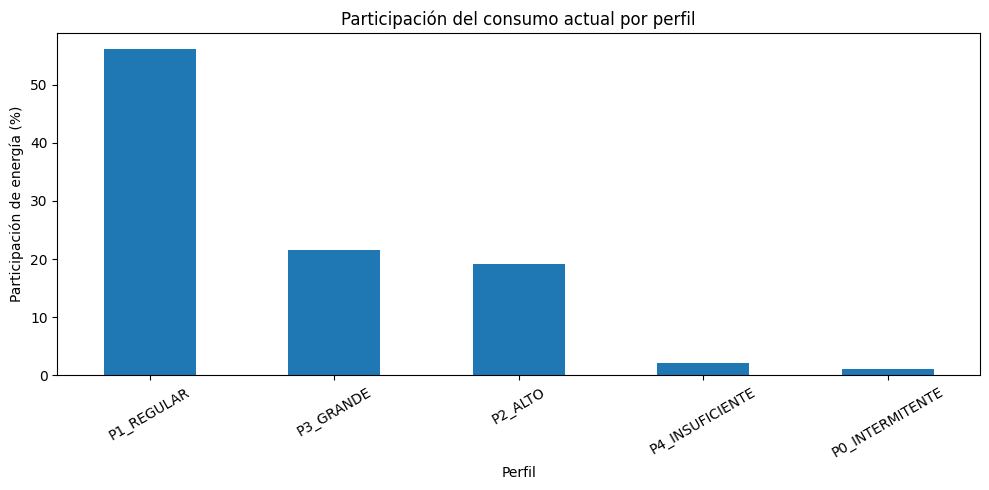

In [12]:
# ============================================================
# 12. GRÁFICA DE COMPOSICIÓN POR PERFIL
# ============================================================

plot_perfiles = (
    resumen_perfiles_final
    .sort_values(
        "participacion_energia_pct",
        ascending=False,
    )
)

ax = plot_perfiles.plot(
    x="perfil",
    y="participacion_energia_pct",
    kind="bar",
    figsize=(10, 5),
    legend=False,
)

ax.set_title(
    "Participación del consumo actual por perfil"
)

ax.set_xlabel(
    "Perfil"
)

ax.set_ylabel(
    "Participación de energía (%)"
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Features de los modelos especializados

Cada modelo recibe únicamente información conocida hasta la fecha de corte:

- consumo actual;
- lags 1–12 y lag 24;
- mismo mes del año anterior;
- mismo mes de hace 2 años;
- medias, medianas y volatilidad;
- ceros recientes;
- crecimiento reciente;
- régimen observado/reconstruido;
- mes objetivo.

`NIU` nunca se utiliza como predictor.

In [13]:
# ============================================================
# 13. CONSTRUIR FEATURES
# ============================================================

FEATURES = [
    "consumo_actual",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "lag_5",
    "lag_6",
    "lag_12",
    "lag_24",
    "media_3m",
    "media_6m",
    "media_12m",
    "mediana_12m",
    "std_3m",
    "std_6m",
    "std_12m",
    "min_6m",
    "max_6m",
    "max_12m",
    "pct_ceros_6m",
    "pct_ceros_12m",
    "variacion_1m",
    "variacion_3m",
    "ratio_actual_media6",
    "mismo_mes_anio_anterior",
    "mismo_mes_2_anios",
    "reconstruido_actual",
    "pct_reconstruido_12m",
    "mes_objetivo",
    "mes_sin",
    "mes_cos",
]


def crear_features(
    fecha_corte,
    horizonte,
    indices,
):
    fecha_corte = periodo_mes(
        fecha_corte
    )

    fecha_objetivo = sumar_meses(
        fecha_corte,
        horizonte,
    )

    actual = valores_mes(
        fecha_corte,
        indices,
    )

    lags = {
        lag: valores_mes(
            sumar_meses(
                fecha_corte,
                -lag,
            ),
            indices,
        )
        for lag in [
            1, 2, 3, 4, 5, 6, 12, 24
        ]
    }

    v3 = ventana_consumo(
        fecha_corte,
        3,
        indices,
    )

    v6 = ventana_consumo(
        fecha_corte,
        6,
        indices,
    )

    v12 = ventana_consumo(
        fecha_corte,
        12,
        indices,
    )

    media6 = media_nan(v6)

    validos6 = np.sum(
        ~np.isnan(v6),
        axis=1,
    )

    validos12 = np.sum(
        ~np.isnan(v12),
        axis=1,
    )

    ceros6 = np.sum(
        np.where(
            np.isnan(v6),
            False,
            v6 == 0,
        ),
        axis=1,
    )

    ceros12 = np.sum(
        np.where(
            np.isnan(v12),
            False,
            v12 == 0,
        ),
        axis=1,
    )

    pct_ceros6 = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    pct_ceros12 = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    mask6 = validos6 > 0
    mask12 = validos12 > 0

    pct_ceros6[mask6] = (
        ceros6[mask6]
        / validos6[mask6]
    )

    pct_ceros12[mask12] = (
        ceros12[mask12]
        / validos12[mask12]
    )

    ratio = np.full(
        len(indices),
        np.nan,
        dtype="float32",
    )

    mask_ratio = (
        np.isfinite(actual)
        & np.isfinite(media6)
        & (media6 != 0)
    )

    ratio[mask_ratio] = (
        actual[mask_ratio]
        / media6[mask_ratio]
    )

    mismo_mes_1a = valores_mes(
        sumar_meses(
            fecha_objetivo,
            -12,
        ),
        indices,
    )

    mismo_mes_2a = valores_mes(
        sumar_meses(
            fecha_objetivo,
            -24,
        ),
        indices,
    )

    reconstruido_actual = (
        valores_regimen_mes(
            fecha_corte,
            indices,
        )
    )

    if matriz_reconstruido is not None:
        vr12 = ventana_regimen(
            fecha_corte,
            12,
            indices,
        )

        pct_reconstruido12 = (
            media_nan(vr12)
        )
    else:
        pct_reconstruido12 = np.full(
            len(indices),
            np.nan,
            dtype="float32",
        )

    mes_obj = fecha_objetivo.month

    X = pd.DataFrame(
        {
            "consumo_actual":
                actual,

            "lag_1":
                lags[1],

            "lag_2":
                lags[2],

            "lag_3":
                lags[3],

            "lag_4":
                lags[4],

            "lag_5":
                lags[5],

            "lag_6":
                lags[6],

            "lag_12":
                lags[12],

            "lag_24":
                lags[24],

            "media_3m":
                media_nan(v3),

            "media_6m":
                media6,

            "media_12m":
                media_nan(v12),

            "mediana_12m":
                mediana_nan(v12),

            "std_3m":
                std_nan(v3),

            "std_6m":
                std_nan(v6),

            "std_12m":
                std_nan(v12),

            "min_6m":
                min_nan(v6),

            "max_6m":
                max_nan(v6),

            "max_12m":
                max_nan(v12),

            "pct_ceros_6m":
                pct_ceros6,

            "pct_ceros_12m":
                pct_ceros12,

            "variacion_1m":
                (
                    actual
                    - lags[1]
                ).astype("float32"),

            "variacion_3m":
                (
                    actual
                    - lags[3]
                ).astype("float32"),

            "ratio_actual_media6":
                ratio,

            "mismo_mes_anio_anterior":
                mismo_mes_1a,

            "mismo_mes_2_anios":
                mismo_mes_2a,

            "reconstruido_actual":
                reconstruido_actual,

            "pct_reconstruido_12m":
                pct_reconstruido12,

            "mes_objetivo":
                np.full(
                    len(indices),
                    mes_obj,
                    dtype="float32",
                ),

            "mes_sin":
                np.full(
                    len(indices),
                    np.sin(
                        2
                        * np.pi
                        * mes_obj
                        / 12
                    ),
                    dtype="float32",
                ),

            "mes_cos":
                np.full(
                    len(indices),
                    np.cos(
                        2
                        * np.pi
                        * mes_obj
                        / 12
                    ),
                    dtype="float32",
                ),
        }
    )

    return X[
        FEATURES
    ], fecha_objetivo

In [14]:
# ============================================================
# 14. MÉTRICAS Y BASELINE
# ============================================================

def metricas_regresion(
    real,
    pred,
):
    real = np.asarray(
        real,
        dtype="float64",
    )

    pred = np.asarray(
        pred,
        dtype="float64",
    )

    mask = (
        np.isfinite(real)
        & np.isfinite(pred)
    )

    real = real[mask]
    pred = pred[mask]

    if len(real) == 0:
        return {
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "WAPE_pct": np.nan,
            "sMAPE_pct": np.nan,
            "R2": np.nan,
            "sesgo_pct": np.nan,
        }

    mae = mean_absolute_error(
        real,
        pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            real,
            pred,
        )
    )

    suma_real = np.abs(
        real
    ).sum()

    wape = (
        np.abs(
            real - pred
        ).sum()
        / suma_real
        * 100
        if suma_real > 0
        else np.nan
    )

    denom = (
        np.abs(real)
        + np.abs(pred)
    )

    mask_smape = denom > 0

    smape = (
        np.mean(
            2
            * np.abs(
                real[mask_smape]
                - pred[mask_smape]
            )
            / denom[mask_smape]
        )
        * 100
        if mask_smape.any()
        else 0.0
    )

    r2 = (
        r2_score(
            real,
            pred,
        )
        if len(real) > 1
        else np.nan
    )

    sesgo = (
        (
            pred.sum()
            - real.sum()
        )
        / real.sum()
        * 100
        if real.sum() != 0
        else np.nan
    )

    return {
        "n": int(len(real)),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "WAPE_pct": float(wape),
        "sMAPE_pct": float(smape),
        "R2": float(r2),
        "sesgo_pct": float(sesgo),
    }


def baseline_hibrido(
    fecha_corte,
    horizonte,
    indices,
):
    fecha_target = sumar_meses(
        fecha_corte,
        horizonte,
    )

    estacional = valores_mes(
        sumar_meses(
            fecha_target,
            -12,
        ),
        indices,
    )

    actual = valores_mes(
        fecha_corte,
        indices,
    )

    return np.where(
        np.isfinite(estacional),
        estacional,
        actual,
    ).astype("float32")

# Modelos por perfil

Se utilizan modelos independientes por horizonte.

Esto evita que `t+1` y `t+6` tengan que compartir exactamente la misma relación de aprendizaje.

In [15]:
# ============================================================
# 15. FÁBRICAS DE MODELOS ESPECIALIZADOS
# ============================================================

def nuevo_modelo_hurdle_classifier():
    return LGBMClassifier(
        objective="binary",
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=0.50,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )


def nuevo_modelo_log():
    return LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.04,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.05,
        reg_lambda=0.50,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )


def nuevo_modelo_tweedie(
    gran_consumidor=False,
):
    return LGBMRegressor(
        objective="tweedie",
        tweedie_variance_power=1.5,
        n_estimators=(
            650
            if gran_consumidor
            else 550
        ),
        learning_rate=0.035,
        num_leaves=(
            31
            if gran_consumidor
            else 63
        ),
        min_child_samples=(
            20
            if gran_consumidor
            else 50
        ),
        subsample=0.95,
        colsample_bytree=0.95,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )

In [16]:
# ============================================================
# 16. CONSTRUIR TRAIN PARA UN PERFIL Y HORIZONTE
# ============================================================

def construir_train_perfil_h(
    perfil,
    horizonte,
    max_target_train,
    seed,
):
    rng = np.random.default_rng(
        seed
    )

    max_target_train = periodo_mes(
        max_target_train
    )

    ultimo_origen = sumar_meses(
        max_target_train,
        -horizonte,
    )

    origenes = pd.date_range(
        start=PRIMER_ORIGEN_TRAIN,
        end=ultimo_origen,
        freq="MS",
    )

    X_partes = []
    y_partes = []
    auditoria = []

    limite = (
        MAX_MUESTRA_POR_ORIGEN[
            perfil
        ]
    )

    for numero, origen in enumerate(
        origenes,
        start=1,
    ):
        perfiles_origen = calcular_perfiles(
            origen
        )

        idx_perfil = (
            perfiles_origen.loc[
                perfiles_origen[
                    "perfil"
                ].eq(perfil),
                "indice",
            ]
            .to_numpy(
                dtype="int64"
            )
        )

        if len(idx_perfil) == 0:
            continue

        y_all, fecha_target = (
            target_horizonte(
                origen,
                horizonte,
                idx_perfil,
            )
        )

        candidatos = idx_perfil[
            np.isfinite(
                y_all
            )
        ]

        if len(candidatos) == 0:
            continue

        if (
            limite is not None
            and len(candidatos) > limite
        ):
            seleccion = rng.choice(
                candidatos,
                size=limite,
                replace=False,
            )
        else:
            seleccion = candidatos

        y_sel, _ = target_horizonte(
            origen,
            horizonte,
            seleccion,
        )

        X_sel, _ = crear_features(
            origen,
            horizonte,
            seleccion,
        )

        X_partes.append(
            X_sel
        )

        y_partes.append(
            y_sel.astype(
                "float32"
            )
        )

        auditoria.append(
            {
                "perfil":
                    perfil,

                "horizonte":
                    horizonte,

                "origen":
                    origen,

                "target":
                    fecha_target,

                "candidatos":
                    len(candidatos),

                "muestra":
                    len(seleccion),
            }
        )

        if (
            numero == 1
            or numero % 6 == 0
            or numero == len(origenes)
        ):
            print(
                f"{perfil} | h={horizonte} | "
                f"{numero}/{len(origenes)} | "
                f"origen={origen:%Y-%m} | "
                f"muestra={len(seleccion):,}"
            )

        del perfiles_origen
        del X_sel
        gc.collect()

    if not X_partes:
        return (
            pd.DataFrame(
                columns=FEATURES
            ),
            np.array(
                [],
                dtype="float32",
            ),
            pd.DataFrame(),
        )

    X = pd.concat(
        X_partes,
        ignore_index=True,
    )

    y = np.concatenate(
        y_partes
    ).astype("float32")

    auditoria = pd.DataFrame(
        auditoria
    )

    del X_partes
    del y_partes
    gc.collect()

    return X, y, auditoria

In [17]:
# ============================================================
# 17. ENTRENAR UN MODELO ESPECIALIZADO
# ============================================================

def entrenar_modelo_perfil(
    perfil,
    X,
    y,
):
    if len(y) == 0:
        return None

    if perfil == "P0_INTERMITENTE":

        y_bin = (
            y > 0
        ).astype("int8")

        modelo = {
            "tipo":
                "hurdle",

            "prob_constante":
                float(
                    y_bin.mean()
                ),

            "classifier":
                None,

            "regressor":
                None,
        }

        if np.unique(
            y_bin
        ).size >= 2:

            clf = (
                nuevo_modelo_hurdle_classifier()
            )

            clf.fit(
                X,
                y_bin,
            )

            modelo[
                "classifier"
            ] = clf

        positivos = (
            y > 0
        )

        if positivos.any():

            reg = nuevo_modelo_log()

            reg.fit(
                X.loc[
                    positivos
                ],
                np.log1p(
                    y[
                        positivos
                    ]
                ),
            )

            modelo[
                "regressor"
            ] = reg

        return modelo

    if perfil == "P1_REGULAR":

        reg = nuevo_modelo_log()

        reg.fit(
            X,
            np.log1p(
                np.maximum(
                    y,
                    0,
                )
            ),
        )

        return {
            "tipo":
                "log",

            "regressor":
                reg,
        }

    if perfil in [
        "P2_ALTO",
        "P3_GRANDE",
    ]:

        reg = nuevo_modelo_tweedie(
            gran_consumidor=(
                perfil
                == "P3_GRANDE"
            )
        )

        reg.fit(
            X,
            np.maximum(
                y,
                0,
            ),
        )

        return {
            "tipo":
                "tweedie",

            "regressor":
                reg,
        }

    raise ValueError(
        f"Perfil no reconocido: {perfil}"
    )


def predecir_modelo_perfil(
    modelo,
    X,
):
    if modelo is None:
        return np.full(
            len(X),
            np.nan,
            dtype="float32",
        )

    tipo = modelo[
        "tipo"
    ]

    if tipo == "hurdle":

        if (
            modelo[
                "classifier"
            ]
            is None
        ):
            p_pos = np.full(
                len(X),
                modelo[
                    "prob_constante"
                ],
                dtype="float32",
            )
        else:
            p_pos = (
                modelo[
                    "classifier"
                ]
                .predict_proba(
                    X
                )[:, 1]
                .astype(
                    "float32"
                )
            )

        if (
            modelo[
                "regressor"
            ]
            is None
        ):
            consumo_positivo = np.zeros(
                len(X),
                dtype="float32",
            )
        else:
            consumo_positivo = np.maximum(
                np.expm1(
                    modelo[
                        "regressor"
                    ].predict(
                        X
                    )
                ),
                0,
            ).astype("float32")

        return (
            p_pos
            * consumo_positivo
        ).astype("float32")

    if tipo == "log":
        return np.maximum(
            np.expm1(
                modelo[
                    "regressor"
                ].predict(
                    X
                )
            ),
            0,
        ).astype("float32")

    if tipo == "tweedie":
        return np.maximum(
            modelo[
                "regressor"
            ].predict(
                X
            ),
            0,
        ).astype("float32")

    raise ValueError(
        f"Tipo de modelo no reconocido: {tipo}"
    )

In [18]:
# ============================================================
# 18. ENTRENAR MODELOS DE COMPARACIÓN
# ============================================================

modelos_comparacion = {}
auditorias_train = []

PERFILES_MODELADOS = [
    "P0_INTERMITENTE",
    "P1_REGULAR",
    "P2_ALTO",
    "P3_GRANDE",
]

for perfil in PERFILES_MODELADOS:

    for h in HORIZONTES:

        print("\n" + "=" * 70)
        print(
            f"ENTRENANDO {perfil} | h={h}"
        )
        print("=" * 70)

        inicio = time.time()

        X_train, y_train, audit = (
            construir_train_perfil_h(
                perfil=perfil,
                horizonte=h,
                max_target_train=
                    MAX_TARGET_TRAIN_COMPARACION,
                seed=(
                    SEED
                    + h
                ),
            )
        )

        print(
            "Train:",
            X_train.shape,
            y_train.shape
        )

        modelo = entrenar_modelo_perfil(
            perfil,
            X_train,
            y_train,
        )

        modelos_comparacion[
            (
                perfil,
                h,
            )
        ] = modelo

        if not audit.empty:
            auditorias_train.append(
                audit
            )

        print(
            "Tiempo total:",
            f"{(time.time() - inicio) / 60:.2f} min"
        )

        del X_train
        del y_train
        gc.collect()


ENTRENANDO P0_INTERMITENTE | h=1
P0_INTERMITENTE | h=1 | 1/18 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=1 | 6/18 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 12/18 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=1 | 18/18 | origen=2024-06 | muestra=40,000
Train: (720000, 31) (720000,)
Tiempo total: 0.51 min

ENTRENANDO P0_INTERMITENTE | h=2
P0_INTERMITENTE | h=2 | 1/17 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=2 | 6/17 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=2 | 12/17 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=2 | 17/17 | origen=2024-05 | muestra=40,000
Train: (680000, 31) (680000,)
Tiempo total: 0.47 min

ENTRENANDO P0_INTERMITENTE | h=3
P0_INTERMITENTE | h=3 | 1/16 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=3 | 6/16 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=3 | 12/16 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=3 | 16/16 | origen=2024-04 | muestra=40,000
Train: (640000, 31) (640000,)


In [19]:
# ============================================================
# 19. GENERAR PREDICCIONES DE UN CORTE
# ============================================================

def predecir_corte_segmentado(
    modelos,
    fecha_corte,
    exigir_target=True,
):
    fecha_corte = periodo_mes(
        fecha_corte
    )

    perfiles_corte = calcular_perfiles(
        fecha_corte
    )

    partes = []

    for h in HORIZONTES:

        fecha_target = sumar_meses(
            fecha_corte,
            h,
        )

        for perfil in PERFILES:

            indices = (
                perfiles_corte.loc[
                    perfiles_corte[
                        "perfil"
                    ].eq(perfil),
                    "indice",
                ]
                .to_numpy(
                    dtype="int64"
                )
            )

            if len(indices) == 0:
                continue

            if exigir_target:

                y_real, _ = (
                    target_horizonte(
                        fecha_corte,
                        h,
                        indices,
                    )
                )

                mask_real = (
                    np.isfinite(
                        y_real
                    )
                )

                indices = indices[
                    mask_real
                ]

                y_real = y_real[
                    mask_real
                ]

                if len(indices) == 0:
                    continue

            else:
                y_real = np.full(
                    len(indices),
                    np.nan,
                    dtype="float32",
                )

            baseline = baseline_hibrido(
                fecha_corte,
                h,
                indices,
            )

            if perfil == "P4_INSUFICIENTE":

                pred_ml = baseline.copy()

            else:

                X, _ = crear_features(
                    fecha_corte,
                    h,
                    indices,
                )

                modelo = modelos[
                    (
                        perfil,
                        h,
                    )
                ]

                pred_ml = (
                    predecir_modelo_perfil(
                        modelo,
                        X,
                    )
                )

                del X

            regimen_actual = (
                valores_regimen_mes(
                    fecha_corte,
                    indices,
                )
            )

            regimen = np.where(
                regimen_actual == 1,
                "reconstruido",
                np.where(
                    regimen_actual == 0,
                    "observado",
                    "sin_dato",
                ),
            )

            temp = pd.DataFrame(
                {
                    "NIU":
                        nius[
                            indices
                        ],

                    "indice":
                        indices,

                    "fecha_corte":
                        fecha_corte,

                    "horizonte":
                        h,

                    "fecha_target":
                        fecha_target,

                    "perfil":
                        perfil,

                    "regimen_actual":
                        regimen,

                    "real_kwh":
                        y_real,

                    "pred_ml_kwh":
                        pred_ml,

                    "baseline_kwh":
                        baseline,
                }
            )

            partes.append(
                temp
            )

            del temp
            gc.collect()

    return pd.concat(
        partes,
        ignore_index=True,
    )

# Optimización del blend ML + baseline

Para cada `perfil × horizonte` se busca un `alpha` en validación:

\[
pred = \alpha \cdot ML + (1-\alpha)\cdot baseline
\]

- `alpha = 1`: solo ML.
- `alpha = 0`: solo baseline.
- valores intermedios: combinación.

Esto es especialmente importante para grandes consumidores y horizontes largos.

In [20]:
# ============================================================
# 20. GENERAR VALIDACIONES
# ============================================================

validaciones = []

for corte in CORTES_VALIDACION:

    print(
        "\nVALIDACIÓN:",
        corte.strftime("%Y-%m")
    )

    temp = predecir_corte_segmentado(
        modelos_comparacion,
        corte,
        exigir_target=True,
    )

    temp[
        "corte_validacion"
    ] = corte

    validaciones.append(
        temp
    )

validacion_detalle = pd.concat(
    validaciones,
    ignore_index=True,
)

print(
    "Filas validación:",
    f"{len(validacion_detalle):,}"
)

display(
    validacion_detalle.head()
)


VALIDACIÓN: 2024-07

VALIDACIÓN: 2025-01
Filas validación: 6,774,019


,NIU,indice,fecha_corte,horizonte,fecha_target,perfil,regimen_actual,real_kwh,pred_ml_kwh,baseline_kwh,corte_validacion
0,100001726,6,2024-07-01,1,2024-08-01,P0_INTERMITENTE,reconstruido,0.000000,2.614864,11.045977,2024-07-01
1,100002503,7,2024-07-01,1,2024-08-01,P0_INTERMITENTE,reconstruido,10.782609,11.347555,22.281250,2024-07-01
2,100005854,11,2024-07-01,1,2024-08-01,P0_INTERMITENTE,reconstruido,6.402174,4.807798,0.000000,2024-07-01
3,100006631,12,2024-07-01,1,2024-08-01,P0_INTERMITENTE,reconstruido,28.641304,24.175148,0.000000,2024-07-01
4,100008205,14,2024-07-01,1,2024-08-01,P0_INTERMITENTE,reconstruido,0.336957,0.777036,1.823529,2024-07-01


In [21]:
# ============================================================
# 21. OPTIMIZAR ALPHA POR PERFIL Y HORIZONTE
# ============================================================

filas_alpha = []

for perfil in PERFILES:

    for h in HORIZONTES:

        g = validacion_detalle[
            validacion_detalle[
                "perfil"
            ].eq(perfil)
            & validacion_detalle[
                "horizonte"
            ].eq(h)
        ].copy()

        g = g[
            np.isfinite(
                g["real_kwh"]
            )
            & np.isfinite(
                g["pred_ml_kwh"]
            )
            & np.isfinite(
                g["baseline_kwh"]
            )
        ]

        if g.empty:
            continue

        real = g[
            "real_kwh"
        ].to_numpy()

        ml = g[
            "pred_ml_kwh"
        ].to_numpy()

        base = g[
            "baseline_kwh"
        ].to_numpy()

        mejor_alpha = None
        mejor_wape = np.inf

        for alpha in GRID_ALPHA:

            pred = (
                alpha
                * ml
                + (
                    1 - alpha
                )
                * base
            )

            met = metricas_regresion(
                real,
                pred,
            )

            if (
                met["WAPE_pct"]
                < mejor_wape
            ):
                mejor_wape = (
                    met["WAPE_pct"]
                )

                mejor_alpha = (
                    alpha
                )

        filas_alpha.append(
            {
                "perfil":
                    perfil,

                "horizonte":
                    h,

                "alpha_ml":
                    mejor_alpha,

                "alpha_baseline":
                    1 - mejor_alpha,

                "WAPE_validacion_optimo_pct":
                    mejor_wape,

                "n_validacion":
                    len(g),
            }
        )

alpha_tabla = pd.DataFrame(
    filas_alpha
)

display(
    alpha_tabla.sort_values(
        [
            "perfil",
            "horizonte",
        ]
    )
)

alpha_tabla.to_csv(
    RUTA_ALPHA,
    index=False,
    encoding="utf-8-sig",
)

,perfil,horizonte,alpha_ml,alpha_baseline,WAPE_validacion_optimo_pct,n_validacion
0,P0_INTERMITENTE,1,1.00,0.00,48.182144,213220
1,P0_INTERMITENTE,2,1.00,0.00,53.944709,213184
2,P0_INTERMITENTE,3,1.00,0.00,71.366157,213083
3,P0_INTERMITENTE,4,1.00,0.00,78.898085,212884
4,P0_INTERMITENTE,5,1.00,0.00,79.813781,212956
5,P0_INTERMITENTE,6,1.00,0.00,81.969911,212671
6,P1_REGULAR,1,1.00,0.00,15.882066,871858
7,P1_REGULAR,2,1.00,0.00,17.518547,871844
8,P1_REGULAR,3,1.00,0.00,21.853382,871770
9,P1_REGULAR,4,0.95,0.05,23.939647,871658


In [22]:
# ============================================================
# 22. APLICAR ALPHA
# ============================================================

mapa_alpha = {
    (
        fila.perfil,
        int(
            fila.horizonte
        ),
    ):
        float(
            fila.alpha_ml
        )
    for fila
    in alpha_tabla.itertuples(
        index=False
    )
}


def aplicar_blend(
    df_pred,
):
    df = df_pred.copy()

    alphas = np.array(
        [
            mapa_alpha.get(
                (
                    perfil,
                    int(h),
                ),
                0.0
                if perfil
                == "P4_INSUFICIENTE"
                else 1.0,
            )
            for perfil, h
            in zip(
                df["perfil"],
                df["horizonte"],
            )
        ],
        dtype="float32",
    )

    df[
        "alpha_ml"
    ] = alphas

    df[
        "pred_final_kwh"
    ] = (
        alphas
        * df[
            "pred_ml_kwh"
        ].to_numpy()
        + (
            1 - alphas
        )
        * df[
            "baseline_kwh"
        ].to_numpy()
    ).astype("float32")

    df[
        "pred_final_kwh"
    ] = np.maximum(
        df[
            "pred_final_kwh"
        ],
        0,
    )

    return df


validacion_detalle = aplicar_blend(
    validacion_detalle
)

In [23]:
# ============================================================
# 23. MÉTRICAS DE VALIDACIÓN POR PERFIL Y HORIZONTE
# ============================================================

filas_metricas_validacion = []

for (
    perfil,
    h,
), g in validacion_detalle.groupby(
    [
        "perfil",
        "horizonte",
    ]
):

    met_modelo = metricas_regresion(
        g[
            "real_kwh"
        ],
        g[
            "pred_final_kwh"
        ],
    )

    met_base = metricas_regresion(
        g[
            "real_kwh"
        ],
        g[
            "baseline_kwh"
        ],
    )

    filas_metricas_validacion.append(
        {
            "perfil":
                perfil,

            "horizonte":
                h,

            **{
                f"modelo_{k}":
                    v
                for k, v
                in met_modelo.items()
            },

            **{
                f"baseline_{k}":
                    v
                for k, v
                in met_base.items()
            },
        }
    )

metricas_validacion = pd.DataFrame(
    filas_metricas_validacion
)

display(
    metricas_validacion.sort_values(
        [
            "perfil",
            "horizonte",
        ]
    )
)

metricas_validacion.to_csv(
    RUTA_METRICAS_VALIDACION,
    index=False,
    encoding="utf-8-sig",
)

,perfil,horizonte,modelo_n,modelo_MAE,modelo_RMSE,modelo_WAPE_pct,modelo_sMAPE_pct,modelo_R2,modelo_sesgo_pct,baseline_n,baseline_MAE,baseline_RMSE,baseline_WAPE_pct,baseline_sMAPE_pct,baseline_R2,baseline_sesgo_pct
0,P0_INTERMITENTE,1,213220,4.430020,107.875500,48.182144,101.842389,0.150920,-25.769869,213220,12.982531,201.313274,141.201644,119.281027,-1.956976,-3.590358
1,P0_INTERMITENTE,2,213184,5.152507,103.528855,53.944709,102.496275,0.139225,-28.886076,213184,12.384631,139.979023,129.662181,120.098875,-0.573593,-19.572597
2,P0_INTERMITENTE,3,213083,7.660062,137.468208,71.366157,114.360558,0.068911,-39.079421,213083,12.737999,180.468212,118.675539,116.997491,-0.604678,-35.308193
3,P0_INTERMITENTE,4,212884,9.040979,201.643322,78.898085,121.041236,0.025556,-47.199420,212884,12.543355,209.984402,109.462333,120.518629,-0.056728,-54.704094
4,P0_INTERMITENTE,5,212956,9.145154,103.760093,79.813781,120.957052,0.075144,-45.436163,212956,12.387386,125.209695,108.110156,120.775473,-0.346758,-56.821888
5,P0_INTERMITENTE,6,212671,10.156975,95.544038,81.969911,119.257501,0.079821,-47.600524,212671,12.492322,116.221009,100.816881,118.131363,-0.361553,-63.079393
6,P1_REGULAR,1,871858,13.981002,84.966490,15.882066,20.742102,0.442868,-1.839285,871858,29.919861,102.715797,33.988209,39.931040,0.185788,2.395098
7,P1_REGULAR,2,871844,14.902680,46.729614,17.518547,22.400618,0.694132,-4.255548,871844,28.857501,71.999204,33.922859,39.611759,0.273886,2.989488
8,P1_REGULAR,3,871770,19.507167,54.331133,21.853382,27.910624,0.633722,-7.643301,871770,30.393449,95.573282,34.049006,39.384129,-0.133408,2.541935
9,P1_REGULAR,4,871658,21.013365,61.000577,23.939647,30.494687,0.556191,-9.520819,871658,29.195818,95.233800,33.261572,39.336339,-0.081710,1.135919


In [24]:
# ============================================================
# 24. BACKTEST FINAL 2025-07 -> 2026-01
# ============================================================

backtest = (
    predecir_corte_segmentado(
        modelos_comparacion,
        CORTE_BACKTEST_FINAL,
        exigir_target=True,
    )
)

backtest = aplicar_blend(
    backtest
)

print(
    "Filas backtest:",
    f"{len(backtest):,}"
)

display(
    backtest.head(20)
)

Filas backtest: 3,443,328


,NIU,indice,fecha_corte,horizonte,fecha_target,perfil,regimen_actual,real_kwh,pred_ml_kwh,baseline_kwh,alpha_ml,pred_final_kwh
0,100001726,6,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,0.000000,0.114984,0.000000,1.0,0.114984
1,100005854,11,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,7.000000,5.925604,6.402174,1.0,5.925604
2,100008205,14,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,0.336957,0.379680,0.336957,1.0,0.379680
3,100010818,18,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,0.000000,0.020638,0.000000,1.0,0.020638
4,100012482,20,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.684783,2.833310,4.043478,1.0,2.833310
5,1000127971,21,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,0.000000,0.065566,0.000000,1.0,0.065566
6,100013269,26,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,0.000000,0.127750,10.445652,1.0,0.127750
7,100016500,35,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,5.701149,6.305818,26.956522,1.0,6.305818
8,1000201208,52,2025-07-01,1,2025-08-01,P0_INTERMITENTE,observado,0.000000,0.585711,0.000000,1.0,0.585711
9,1000211177,59,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,0.000000,0.112446,11.094737,1.0,0.112446


In [25]:
# ============================================================
# 25. MÉTRICAS BACKTEST POR PERFIL/HORIZONTE
# ============================================================

filas_metricas = []

for (
    perfil,
    h,
), g in backtest.groupby(
    [
        "perfil",
        "horizonte",
    ]
):

    met_modelo = metricas_regresion(
        g[
            "real_kwh"
        ],
        g[
            "pred_final_kwh"
        ],
    )

    met_base = metricas_regresion(
        g[
            "real_kwh"
        ],
        g[
            "baseline_kwh"
        ],
    )

    filas_metricas.append(
        {
            "perfil":
                perfil,

            "horizonte":
                h,

            **{
                f"modelo_{k}":
                    v
                for k, v
                in met_modelo.items()
            },

            **{
                f"baseline_{k}":
                    v
                for k, v
                in met_base.items()
            },
        }
    )

metricas_backtest = pd.DataFrame(
    filas_metricas
)

display(
    metricas_backtest.sort_values(
        [
            "horizonte",
            "perfil",
        ]
    )
)

metricas_backtest.to_csv(
    RUTA_METRICAS_BACKTEST,
    index=False,
    encoding="utf-8-sig",
)

metricas_backtest.to_csv(
    RUTA_METRICAS_PERFIL,
    index=False,
    encoding="utf-8-sig",
)

,perfil,horizonte,modelo_n,modelo_MAE,modelo_RMSE,modelo_WAPE_pct,modelo_sMAPE_pct,modelo_R2,modelo_sesgo_pct,baseline_n,baseline_MAE,baseline_RMSE,baseline_WAPE_pct,baseline_sMAPE_pct,baseline_R2,baseline_sesgo_pct
0,P0_INTERMITENTE,1,109399,3.955640,73.665015,45.587321,103.226807,0.214396,-24.057492,109399,13.144948,194.911628,151.490791,119.801298,-4.499923,8.043616
6,P1_REGULAR,1,443719,13.647587,67.267773,15.271225,20.151232,0.568728,-4.113622,443719,30.055346,82.464415,33.630997,39.562533,0.351857,1.581489
12,P2_ALTO,1,10324,183.590155,906.788127,15.261285,18.430570,0.566742,-2.253929,10324,364.066810,1194.506950,30.263754,31.724024,0.248182,3.655974
18,P3_GRANDE,1,825,2832.059208,8543.698747,14.376872,21.022320,0.971581,-1.665423,825,5010.616829,11740.447944,25.436260,32.528775,0.946335,8.535897
24,P4_INSUFICIENTE,1,5420,86.607655,975.901224,76.982338,62.094141,-0.105072,15.935659,5420,86.607655,975.901224,76.982338,62.094141,-0.105072,15.935659
1,P0_INTERMITENTE,2,109706,5.172505,97.437779,54.900414,104.898774,0.125838,-31.167414,109706,12.856740,165.850411,136.460045,120.787991,-1.532621,-16.221709
7,P1_REGULAR,2,443817,17.115783,52.973204,19.009684,23.597537,0.672340,-10.088488,443817,29.974231,96.309709,33.290950,39.811472,-0.083057,-3.706939
13,P2_ALTO,2,10326,240.939650,1444.705956,19.418638,21.526120,0.344782,-7.212185,10326,397.081343,1686.154291,32.002948,32.741545,0.107472,-2.798170
19,P3_GRANDE,2,824,3680.365776,15281.702530,18.536914,24.058016,0.909407,-4.915742,824,5490.506203,17196.177245,27.654056,32.688018,0.885287,2.140180
25,P4_INSUFICIENTE,2,5419,167.962209,6170.079904,154.099127,68.514208,-56.124147,96.742535,5419,167.962209,6170.079904,154.099127,68.514208,-56.124147,96.742535


In [26]:
# ============================================================
# 26. MÉTRICAS GLOBALES POR HORIZONTE
# ============================================================

filas_globales = []

for h, g in backtest.groupby(
    "horizonte"
):

    modelo = metricas_regresion(
        g[
            "real_kwh"
        ],
        g[
            "pred_final_kwh"
        ],
    )

    baseline = metricas_regresion(
        g[
            "real_kwh"
        ],
        g[
            "baseline_kwh"
        ],
    )

    filas_globales.append(
        {
            "horizonte":
                h,

            "modelo_WAPE_pct":
                modelo[
                    "WAPE_pct"
                ],

            "baseline_WAPE_pct":
                baseline[
                    "WAPE_pct"
                ],

            "modelo_MAE":
                modelo[
                    "MAE"
                ],

            "baseline_MAE":
                baseline[
                    "MAE"
                ],

            "modelo_RMSE":
                modelo[
                    "RMSE"
                ],

            "modelo_R2":
                modelo[
                    "R2"
                ],

            "modelo_sesgo_pct":
                modelo[
                    "sesgo_pct"
                ],

            "n":
                modelo[
                    "n"
                ],
        }
    )

metricas_globales = pd.DataFrame(
    filas_globales
)

display(
    metricas_globales
)

,horizonte,modelo_WAPE_pct,baseline_WAPE_pct,modelo_MAE,baseline_MAE,modelo_RMSE,modelo_R2,modelo_sesgo_pct,n
0,1,16.011725,33.106102,19.641810,40.611723,366.383845,0.969149,-3.309768,569687
1,2,20.626397,34.269953,25.600222,42.533769,860.946797,0.831054,-7.787780,570092
2,3,25.079293,36.527307,28.886587,42.072528,563.456053,0.930147,-1.931729,570309
3,4,24.539701,33.014224,29.644439,39.881828,508.727270,0.935477,-8.277378,570025
4,5,26.391243,34.026305,31.686261,40.853186,544.334893,0.925738,-6.706430,570034
5,6,36.998316,44.211108,40.363667,48.232530,833.091482,0.784839,3.066379,568528


In [27]:
# ============================================================
# 27. MÉTRICAS POR RÉGIMEN OBSERVADO / RECONSTRUIDO
# ============================================================

filas_regimen = []

for (
    regimen,
    h,
), g in backtest.groupby(
    [
        "regimen_actual",
        "horizonte",
    ]
):

    met = metricas_regresion(
        g[
            "real_kwh"
        ],
        g[
            "pred_final_kwh"
        ],
    )

    filas_regimen.append(
        {
            "regimen":
                regimen,

            "horizonte":
                h,

            **met,
        }
    )

metricas_regimen = pd.DataFrame(
    filas_regimen
)

display(
    metricas_regimen.sort_values(
        [
            "regimen",
            "horizonte",
        ]
    )
)

metricas_regimen.to_csv(
    RUTA_METRICAS_REGIMEN,
    index=False,
    encoding="utf-8-sig",
)

,regimen,horizonte,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2,sesgo_pct
0,observado,1,355063,27.852445,462.540386,16.842163,34.349419,0.969286,-4.328328
1,observado,2,354960,37.327461,1090.063440,22.080487,39.367581,0.831003,-8.945561
2,observado,3,355070,35.153478,711.258871,22.076057,39.537224,0.930570,-4.994214
3,observado,4,354842,38.665414,636.846573,23.873025,41.922704,0.936835,-7.933488
4,observado,5,354843,41.471444,680.734561,25.959899,42.817943,0.927469,-5.881483
5,observado,6,355034,47.411602,1052.196564,29.337626,46.518838,0.785230,-6.179227
6,reconstruido,1,214561,6.014198,46.103613,11.558201,39.925502,0.882080,1.971595
7,reconstruido,2,214743,6.043822,49.104940,12.083974,39.790917,0.853604,-1.688403
8,reconstruido,3,214825,18.403608,77.248295,43.309500,67.698131,0.577479,16.909098
9,reconstruido,4,214776,14.732893,129.575875,27.812085,58.927170,0.437834,-10.051849


In [28]:
# ============================================================
# 28. REAL VS PRONOSTICADO DETALLADO
# ============================================================

backtest[
    "error_kwh"
] = (
    backtest[
        "pred_final_kwh"
    ]
    - backtest[
        "real_kwh"
    ]
)

backtest[
    "error_abs_kwh"
] = np.abs(
    backtest[
        "error_kwh"
    ]
)

backtest[
    "error_pct"
] = np.where(
    backtest[
        "real_kwh"
    ] > 0,

    (
        backtest[
            "error_kwh"
        ]
        / backtest[
            "real_kwh"
        ]
        * 100
    ),

    np.nan,
)

columnas_real_vs_pred = [
    "NIU",
    "fecha_corte",
    "horizonte",
    "fecha_target",
    "perfil",
    "regimen_actual",
    "alpha_ml",
    "real_kwh",
    "pred_ml_kwh",
    "baseline_kwh",
    "pred_final_kwh",
    "error_kwh",
    "error_abs_kwh",
    "error_pct",
]

real_vs_pred = backtest[
    columnas_real_vs_pred
].copy()

real_vs_pred.to_parquet(
    RUTA_REAL_VS_PRED,
    index=False,
    engine="pyarrow",
)

display(
    real_vs_pred.head(20)
)

,NIU,fecha_corte,horizonte,fecha_target,perfil,regimen_actual,alpha_ml,real_kwh,pred_ml_kwh,baseline_kwh,pred_final_kwh,error_kwh,error_abs_kwh,error_pct
0,100001726,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,0.000000,0.114984,0.000000,0.114984,0.114984,0.114984,NaN
1,100005854,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,7.000000,5.925604,6.402174,5.925604,-1.074396,1.074396,-15.348516
2,100008205,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,0.336957,0.379680,0.336957,0.379680,0.042724,0.042724,12.679270
3,100010818,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,0.000000,0.020638,0.000000,0.020638,0.020638,0.020638,NaN
4,100012482,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,1.684783,2.833310,4.043478,2.833310,1.148527,1.148527,68.170639
5,1000127971,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,0.000000,0.065566,0.000000,0.065566,0.065566,0.065566,NaN
6,100013269,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,0.000000,0.127750,10.445652,0.127750,0.127750,0.127750,NaN
7,100016500,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,5.701149,6.305818,26.956522,6.305818,0.604669,0.604669,10.606083
8,1000201208,2025-07-01,1,2025-08-01,P0_INTERMITENTE,observado,1.0,0.000000,0.585711,0.000000,0.585711,0.585711,0.585711,NaN
9,1000211177,2025-07-01,1,2025-08-01,P0_INTERMITENTE,reconstruido,1.0,0.000000,0.112446,11.094737,0.112446,0.112446,0.112446,NaN


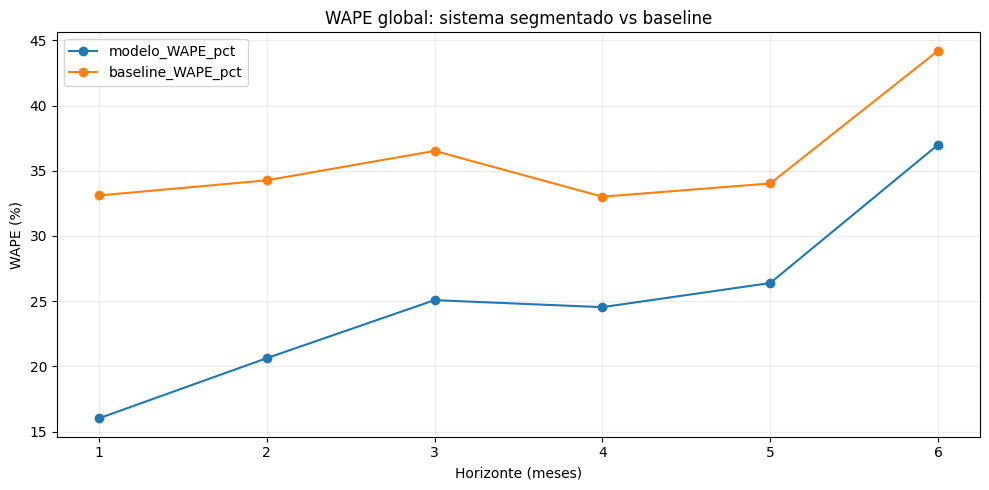

In [29]:
# ============================================================
# 29. GRÁFICA WAPE MODELO VS BASELINE POR HORIZONTE
# ============================================================

graf = (
    metricas_globales
    .set_index(
        "horizonte"
    )[
        [
            "modelo_WAPE_pct",
            "baseline_WAPE_pct",
        ]
    ]
)

ax = graf.plot(
    marker="o",
    figsize=(10, 5),
)

ax.set_title(
    "WAPE global: sistema segmentado vs baseline"
)

ax.set_xlabel(
    "Horizonte (meses)"
)

ax.set_ylabel(
    "WAPE (%)"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

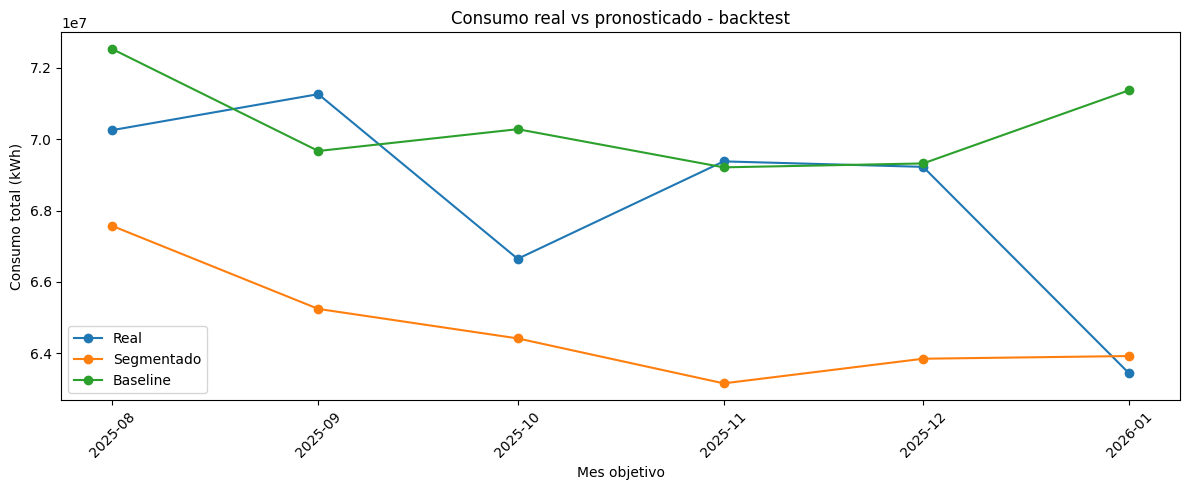

In [30]:
# ============================================================
# 30. GRÁFICA REAL VS PRONOSTICADO TOTAL
# ============================================================

resumen_mensual = (
    backtest
    .groupby(
        [
            "horizonte",
            "fecha_target",
        ],
        as_index=False,
    )
    .agg(
        real_total_kwh=(
            "real_kwh",
            "sum"
        ),
        pronosticado_total_kwh=(
            "pred_final_kwh",
            "sum"
        ),
        baseline_total_kwh=(
            "baseline_kwh",
            "sum"
        ),
    )
    .sort_values(
        "fecha_target"
    )
)

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    resumen_mensual[
        "fecha_target"
    ],
    resumen_mensual[
        "real_total_kwh"
    ],
    marker="o",
    label="Real",
)

plt.plot(
    resumen_mensual[
        "fecha_target"
    ],
    resumen_mensual[
        "pronosticado_total_kwh"
    ],
    marker="o",
    label="Segmentado",
)

plt.plot(
    resumen_mensual[
        "fecha_target"
    ],
    resumen_mensual[
        "baseline_total_kwh"
    ],
    marker="o",
    label="Baseline",
)

plt.title(
    "Consumo real vs pronosticado - backtest"
)

plt.xlabel(
    "Mes objetivo"
)

plt.ylabel(
    "Consumo total (kWh)"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

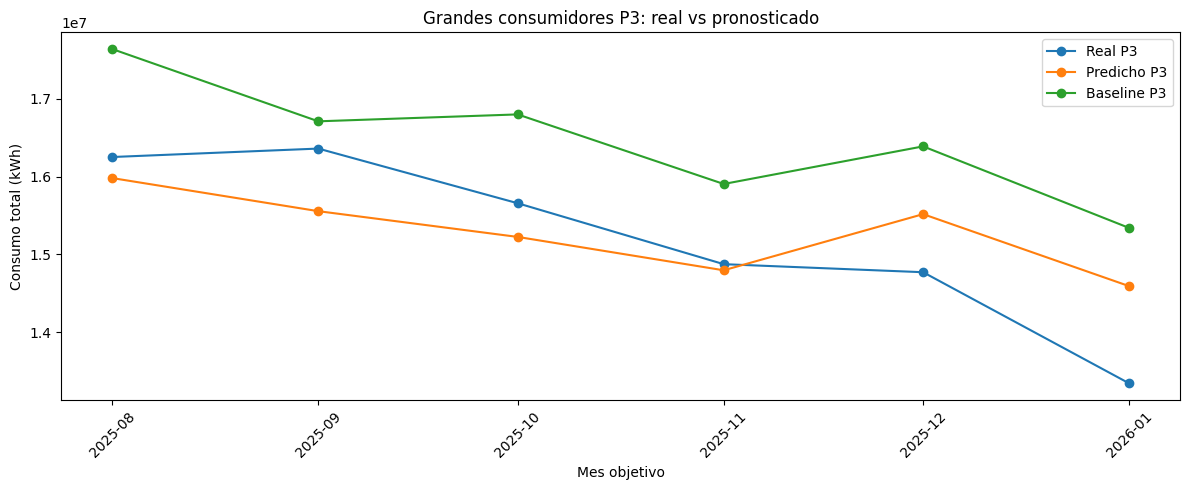

In [31]:
# ============================================================
# 31. GRÁFICA ESPECÍFICA DE GRANDES CONSUMIDORES
# ============================================================

p3_backtest = backtest[
    backtest[
        "perfil"
    ].eq(
        "P3_GRANDE"
    )
].copy()

if not p3_backtest.empty:

    resumen_p3 = (
        p3_backtest
        .groupby(
            [
                "horizonte",
                "fecha_target",
            ],
            as_index=False,
        )
        .agg(
            real_kwh=(
                "real_kwh",
                "sum"
            ),
            pred_kwh=(
                "pred_final_kwh",
                "sum"
            ),
            baseline_kwh=(
                "baseline_kwh",
                "sum"
            ),
        )
    )

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        resumen_p3[
            "fecha_target"
        ],
        resumen_p3[
            "real_kwh"
        ],
        marker="o",
        label="Real P3",
    )

    plt.plot(
        resumen_p3[
            "fecha_target"
        ],
        resumen_p3[
            "pred_kwh"
        ],
        marker="o",
        label="Predicho P3",
    )

    plt.plot(
        resumen_p3[
            "fecha_target"
        ],
        resumen_p3[
            "baseline_kwh"
        ],
        marker="o",
        label="Baseline P3",
    )

    plt.title(
        "Grandes consumidores P3: real vs pronosticado"
    )

    plt.xlabel(
        "Mes objetivo"
    )

    plt.ylabel(
        "Consumo total (kWh)"
    )

    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Reentrenamiento final

Después de validar la arquitectura, se entrenan nuevamente todos los modelos especializados con toda la información conocida hasta el último mes disponible.

Los `alpha` permanecen congelados con los valores obtenidos en validación.

In [32]:
# ============================================================
# 32. ENTRENAR MODELOS FINALES
# ============================================================

modelos_finales = {}

for perfil in PERFILES_MODELADOS:

    for h in HORIZONTES:

        print("\n" + "=" * 70)
        print(
            f"FINAL {perfil} | h={h}"
        )
        print("=" * 70)

        inicio = time.time()

        X_train, y_train, _ = (
            construir_train_perfil_h(
                perfil=perfil,
                horizonte=h,
                max_target_train=
                    FECHA_CORTE_FINAL,
                seed=(
                    SEED
                    + 100
                    + h
                ),
            )
        )

        modelo = entrenar_modelo_perfil(
            perfil,
            X_train,
            y_train,
        )

        modelos_finales[
            (
                perfil,
                h,
            )
        ] = modelo

        print(
            "Tiempo:",
            f"{(time.time() - inicio) / 60:.2f} min"
        )

        del X_train
        del y_train
        gc.collect()


FINAL P0_INTERMITENTE | h=1
P0_INTERMITENTE | h=1 | 1/36 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=1 | 6/36 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 12/36 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=1 | 18/36 | origen=2024-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 24/36 | origen=2024-12 | muestra=40,000
P0_INTERMITENTE | h=1 | 30/36 | origen=2025-06 | muestra=40,000
P0_INTERMITENTE | h=1 | 36/36 | origen=2025-12 | muestra=40,000
Tiempo: 0.99 min

FINAL P0_INTERMITENTE | h=2
P0_INTERMITENTE | h=2 | 1/35 | origen=2023-01 | muestra=40,000
P0_INTERMITENTE | h=2 | 6/35 | origen=2023-06 | muestra=40,000
P0_INTERMITENTE | h=2 | 12/35 | origen=2023-12 | muestra=40,000
P0_INTERMITENTE | h=2 | 18/35 | origen=2024-06 | muestra=40,000
P0_INTERMITENTE | h=2 | 24/35 | origen=2024-12 | muestra=40,000
P0_INTERMITENTE | h=2 | 30/35 | origen=2025-06 | muestra=40,000
P0_INTERMITENTE | h=2 | 35/35 | origen=2025-11 | muestra=40,000
Tiempo: 0.96 min

FINAL P0_INTERM

In [33]:
# ============================================================
# 33. GUARDAR BUNDLE DE MODELOS
# ============================================================

joblib.dump(
    {
        "modelos":
            modelos_finales,

        "alpha":
            mapa_alpha,

        "features":
            FEATURES,

        "config_perfiles":
            {
                "MIN_MESES_VALIDOS_12":
                    MIN_MESES_VALIDOS_12,

                "UMBRAL_MUY_BAJO_KWH":
                    UMBRAL_MUY_BAJO_KWH,

                "UMBRAL_ALTO_KWH":
                    UMBRAL_ALTO_KWH,

                "UMBRAL_GRANDE_KWH":
                    UMBRAL_GRANDE_KWH,

                "PCT_CEROS_INTERMITENTE":
                    PCT_CEROS_INTERMITENTE,
            },

        "fecha_corte":
            FECHA_CORTE_FINAL,

        "horizontes":
            HORIZONTES,
    },
    RUTA_MODELOS,
)

print(
    "Modelos guardados:",
    RUTA_MODELOS
)

Modelos guardados: C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada\modelos_segmentados_consumo.joblib


In [34]:
# ============================================================
# 34. PRONÓSTICO FINAL t+1 A t+6
# ============================================================

pred_final = (
    predecir_corte_segmentado(
        modelos_finales,
        FECHA_CORTE_FINAL,
        exigir_target=False,
    )
)

pred_final = aplicar_blend(
    pred_final
)

# Una fila por NIU y horizonte
pred_final = pred_final[
    [
        "NIU",
        "fecha_corte",
        "horizonte",
        "fecha_target",
        "perfil",
        "regimen_actual",
        "alpha_ml",
        "pred_ml_kwh",
        "baseline_kwh",
        "pred_final_kwh",
    ]
].copy()

print(
    "Filas pronóstico:",
    f"{len(pred_final):,}"
)

display(
    pred_final.head(20)
)

Filas pronóstico: 3,552,954


,NIU,fecha_corte,horizonte,fecha_target,perfil,regimen_actual,alpha_ml,pred_ml_kwh,baseline_kwh,pred_final_kwh
0,100001726,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,0.031537,0.000000,0.031537
1,100005854,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,3.599507,3.862069,3.599507
2,100008205,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,1.211365,0.923077,1.211365
3,100010818,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,0.015884,0.000000,0.015884
4,100012482,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,0.619240,6.769231,0.619240
5,1000127971,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,0.005607,0.608696,0.005607
6,100013269,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,0.040084,0.000000,0.040084
7,100016500,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,0.602000,3.218391,0.602000
8,1000201208,2026-01-01,1,2026-02-01,P0_INTERMITENTE,observado,1.0,0.813438,3.000000,0.813438
9,1000211177,2026-01-01,1,2026-02-01,P0_INTERMITENTE,reconstruido,1.0,0.019588,0.000000,0.019588


In [35]:
# ============================================================
# 35. CONVERTIR PRONÓSTICO A FORMATO ANCHO
# ============================================================

pred_wide = (
    pred_final
    .pivot(
        index=[
            "NIU",
            "fecha_corte",
            "perfil",
            "regimen_actual",
        ],
        columns="horizonte",
        values="pred_final_kwh",
    )
    .reset_index()
)

pred_wide.columns = [
    (
        f"pred_{c}m_kwh"
        if isinstance(
            c,
            (int, np.integer)
        )
        else c
    )
    for c in pred_wide.columns
]

for h in HORIZONTES:

    pred_wide[
        f"fecha_pred_{h}m"
    ] = sumar_meses(
        FECHA_CORTE_FINAL,
        h,
    )

pred_wide[
    "promedio_pred_3m_kwh"
] = pred_wide[
    [
        "pred_1m_kwh",
        "pred_2m_kwh",
        "pred_3m_kwh",
    ]
].mean(
    axis=1
)

pred_wide[
    "promedio_pred_6m_kwh"
] = pred_wide[
    [
        "pred_1m_kwh",
        "pred_2m_kwh",
        "pred_3m_kwh",
        "pred_4m_kwh",
        "pred_5m_kwh",
        "pred_6m_kwh",
    ]
].mean(
    axis=1
)

display(
    pred_wide.head(20)
)

,NIU,fecha_corte,perfil,regimen_actual,pred_1m_kwh,pred_2m_kwh,pred_3m_kwh,pred_4m_kwh,pred_5m_kwh,pred_6m_kwh,fecha_pred_1m,fecha_pred_2m,fecha_pred_3m,fecha_pred_4m,fecha_pred_5m,fecha_pred_6m,promedio_pred_3m_kwh,promedio_pred_6m_kwh
0,1000006589,2026-01-01,P1_REGULAR,observado,88.236046,87.652588,88.640480,79.449814,76.560120,64.683578,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,88.176369,80.870445
1,1000007366,2026-01-01,P1_REGULAR,observado,76.736115,71.634476,75.768425,74.239609,75.081993,71.086037,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,74.713005,74.091103
2,1000008143,2026-01-01,P1_REGULAR,observado,52.440186,50.034492,51.672512,45.940941,46.505745,46.151028,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,51.382397,48.790817
3,100000949,2026-01-01,P1_REGULAR,reconstruido,20.096745,20.640886,26.806471,22.697693,24.072294,27.044209,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,22.514702,23.559717
4,1000009920,2026-01-01,P1_REGULAR,observado,67.348434,65.852135,68.936745,67.156998,66.902969,66.632347,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,67.379097,67.138268
5,1000010766,2026-01-01,P1_REGULAR,observado,89.113159,83.067093,91.323128,86.166794,89.101273,86.084610,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,87.834465,87.476006
6,100001726,2026-01-01,P0_INTERMITENTE,reconstruido,0.031537,0.078136,0.467385,0.659459,0.717481,0.833912,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,0.192353,0.464652
7,100002503,2026-01-01,P1_REGULAR,reconstruido,9.420738,10.083382,10.289112,10.242359,9.227689,10.783380,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,9.931077,10.007776
8,100003390,2026-01-01,P1_REGULAR,reconstruido,15.317241,16.415867,18.783308,19.410175,16.460762,19.307243,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,16.838806,17.615767
9,100004177,2026-01-01,P1_REGULAR,reconstruido,27.388172,28.543783,30.494415,25.564486,26.883799,29.761292,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,28.808790,28.105989


In [36]:
# ============================================================
# 36. GUARDAR SALIDAS DE 3 Y 6 MESES
# ============================================================

cols_base = [
    "NIU",
    "fecha_corte",
    "perfil",
    "regimen_actual",
]

cols_3m = (
    cols_base
    + [
        "fecha_pred_1m",
        "pred_1m_kwh",
        "fecha_pred_2m",
        "pred_2m_kwh",
        "fecha_pred_3m",
        "pred_3m_kwh",
        "promedio_pred_3m_kwh",
    ]
)

cols_6m = (
    cols_base
    + [
        "fecha_pred_1m",
        "pred_1m_kwh",
        "fecha_pred_2m",
        "pred_2m_kwh",
        "fecha_pred_3m",
        "pred_3m_kwh",
        "fecha_pred_4m",
        "pred_4m_kwh",
        "fecha_pred_5m",
        "pred_5m_kwh",
        "fecha_pred_6m",
        "pred_6m_kwh",
        "promedio_pred_3m_kwh",
        "promedio_pred_6m_kwh",
    ]
)

pred_3m = pred_wide[
    cols_3m
].copy()

pred_6m = pred_wide[
    cols_6m
].copy()

pred_3m.to_parquet(
    RUTA_PRED_3M,
    index=False,
    engine="pyarrow",
)

pred_6m.to_parquet(
    RUTA_PRED_6M,
    index=False,
    engine="pyarrow",
)

print("MODELADO SEGMENTADO TERMINADO")
print("=" * 70)

print("\nPerfiles:")
print(" •", RUTA_PERFILES_FINAL)
print(" •", RUTA_GRANDES_FINAL)
print(" •", RUTA_AUDITORIA_UMBRALES)

print("\nValidación:")
print(" •", RUTA_ALPHA)
print(" •", RUTA_METRICAS_VALIDACION)
print(" •", RUTA_METRICAS_BACKTEST)
print(" •", RUTA_METRICAS_PERFIL)
print(" •", RUTA_METRICAS_REGIMEN)
print(" •", RUTA_REAL_VS_PRED)

print("\nModelos:")
print(" •", RUTA_MODELOS)

print("\nPredicciones:")
print(" • 3 meses:", RUTA_PRED_3M)
print(" • 6 meses:", RUTA_PRED_6M)

MODELADO SEGMENTADO TERMINADO

Perfiles:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada\perfiles_consumidores_corte_final.parquet
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada\grandes_consumidores_corte_final.parquet
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada\auditoria_umbrales_grandes_consumidores.csv

Validación:
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada\alpha_blend_por_perfil_horizonte.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada\metricas_segmentadas_validacion.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada\metricas_segmentadas_backtest.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_consumo\modelacion_consumo_segmentada\metricas_por_perfil_horizonte.csv
 • C:\Users\Home\Documents\Datos Ebsa\Serie_tiempo_cons

# Criterio de éxito

La versión segmentada debe evaluarse contra el notebook global anterior.

La mejora será real si:

1. reduce WAPE global;
2. reduce el sesgo de subestimación;
3. mejora especialmente `P2_ALTO` y `P3_GRANDE`;
4. conserva el buen desempeño de `P1_REGULAR`;
5. supera o combina inteligentemente el baseline en horizontes largos;
6. mantiene métricas razonables tanto para consumo observado como reconstruido.

No se debe elegir un modelo solo por R² ni solo por el promedio global. El reporte por perfil es obligatorio para entender dónde se genera el error.